In [1]:
using Optim
using Plots
using Printf
using LinearAlgebra

In [6]:

function barrier_method_vec(f, gs, x0;
    r_vec0::Vector{Float64},
    r_factor=10.0,
    tol=1e-6,
    max_iter=100,
    method=NelderMead(),
    opt_iterations=2000)

    if all(g(x0) >= 0 for g in gs)
        error("Initial point is infeasible for union (all constraints violated)")
    end

    const_ε = 1e-12
    history = [copy(x0)]
    x = copy(x0)
    r_vec = copy(r_vec0)

    for _ in 1:max_iter
        function Q(pt)
            # Infeasible for union: ALL constraints violated
            all(g(pt) >= 0 for g in gs) && return Inf
            val = f(pt)
            for (i, g) in enumerate(gs)
                gv = g(pt)
                # Only penalise the constraint when it is active (gv < 0)
                if gv < 0 && r_vec[i] > const_ε
                    val += (1.0 / r_vec[i]) * (-1.0 / gv)
                end
            end
            return val
        end

        result = optimize(Q, x, method, Optim.Options(iterations=opt_iterations))
        x_new = result.minimizer
        push!(history, copy(x_new))

        norm(x_new - x) < tol && break

        x = x_new
        r_vec .*= r_factor
    end

    return history
end

barrier_method_vec (generic function with 1 method)

In [7]:
f(x)  = x[1]^2 + x[2]^2
g1(x) = 2.0 - x[1]   # x >= 2
g2(x) = 2.0 - x[2]   # y >= 2
gs = [g1, g2]

# Feasible region (union): x >= 2 OR y >= 2
# Infeasible region:       x <  2 AND y < 2
# Theoretical optima: (2, 0) and (0, 2), both with f = 4

x0 = [3.0, 3.0]
@printf("Starting point: x0 = (%.1f, %.1f),  f(x0) = %.1f\n", x0[1], x0[2], f(x0))

Starting point: x0 = (3.0, 3.0),  f(x0) = 18.0


In [8]:
# 5 initial r-vectors from the unit circle (first quadrant)
θ_r_deg = [0.0, 22.5, 45.0, 67.5, 90.0]
r_vec0_list = [[cosd(θ), sind(θ)] for θ in θ_r_deg]

println("Initial r-vectors (unit circle):")
for (i, rv) in enumerate(r_vec0_list)
    @printf("  θ=%5.1f°  r₀ = (%.4f, %.4f)\n", θ_r_deg[i], rv[1], rv[2])
end

# results[i] = trajectory for r_vec0_list[i], starting from x0
results = [
    barrier_method_vec(f, gs, x0; r_vec0=rv, r_factor=10.0, tol=1e-6)
    for rv in r_vec0_list
]

println("\nFinal points reached (union optima: (2,0) and (0,2), f=4):")
for (i, traj) in enumerate(results)
    x_fin = traj[end]
    n_steps = length(traj) - 1
    @printf("  θ=%5.1f°  →  (%.4f, %.4f)  f=%.4f  (%d steps)\n",
        θ_r_deg[i], x_fin[1], x_fin[2], f(x_fin), n_steps)
end

Initial r-vectors (unit circle):


  θ=  0.0°  r₀ = (1.0000, 0.0000)
  θ= 22.5°  r₀ = (0.9239, 0.3827)
  θ= 45.0°  r₀ = (0.7071, 0.7071)
  θ= 67.5°  r₀ = (0.3827, 0.9239)
  θ= 90.0°  r₀ = (0.0000, 1.0000)

Final points reached (union optima: (2,0) and (0,2), f=4):
  θ=  0.0°  →  (0.0000, 2.0000)  f=4.0000  (3 steps)
  θ= 22.5°  →  (2.0000, -0.0001)  f=4.0000  (18 steps)
  θ= 45.0°  →  (2.0000, -0.0000)  f=4.0000  (18 steps)
  θ= 67.5°  →  (-0.0001, 2.0000)  f=4.0000  (18 steps)
  θ= 90.0°  →  (2.0000, 0.0000)  f=4.0000  (3 steps)


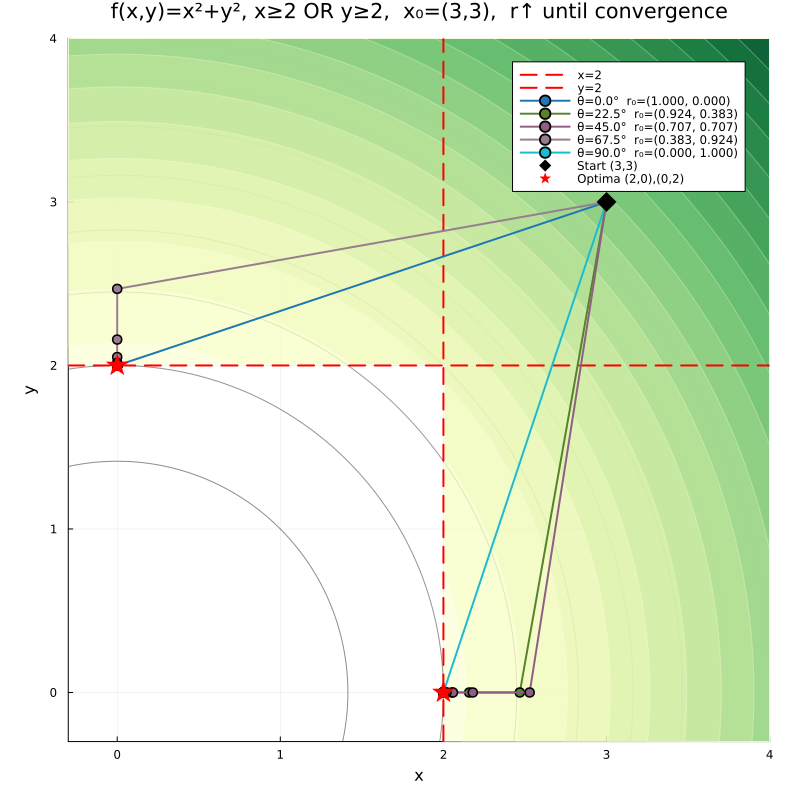

In [9]:
let
    xg = range(-0.3, 4.0, length=400)
    yg = range(-0.3, 4.0, length=400)
    Z      = [x^2 + y^2 for y in yg, x in xg]

    # Union feasible region: x>=2 OR y>=2  (NaN where infeasible)
    Z_feas = [(x >= 2 || y >= 2) ? x^2 + y^2 : NaN for y in yg, x in xg]

    traj_colors = palette(:tab10, length(results))

    p = plot(
        title="f(x,y)=x²+y², x≥2 OR y≥2,  x₀=(3,3),  r↑ until convergence",
        xlabel="x", ylabel="y",
        xlims=(-0.3, 4.0), ylims=(-0.3, 4.0),
        aspect_ratio=:equal,
        size=(800, 800),
        legend=:topright,
    )

    # Contour lines of f
    contour!(p, xg, yg, Z,
        levels=15, lw=1, c=:grays, colorbar=false, alpha=0.5)

    # Union feasible region shading
    contourf!(p, xg, yg, Z_feas,
        levels=20, c=:YlGn, alpha=0.3, colorbar=false)

    # Constraint boundary lines
    vline!(p, [2.0], lw=2, ls=:dash, c=:red, label="x=2")
    hline!(p, [2.0], lw=2, ls=:dash, c=:red, label="y=2")

    # Trajectories, one per r-vector direction
    for (i, traj) in enumerate(results)
        xs = [pt[1] for pt in traj]
        ys = [pt[2] for pt in traj]
        rv = r_vec0_list[i]
        lbl = @sprintf("θ=%.1f°  r₀=(%.3f, %.3f)", θ_r_deg[i], rv[1], rv[2])
        plot!(p, xs, ys,
            lw=2, c=traj_colors[i],
            marker=:circle, ms=5, label=lbl)
    end

    # Starting point
    scatter!(p, [x0[1]], [x0[2]],
        ms=10, marker=:diamond, c=:black, label="Start (3,3)", msc=:auto)

    # Theoretical optima (2,0) and (0,2)
    scatter!(p, [2.0, 0.0], [0.0, 2.0],
        ms=12, marker=:star5, c=:red, label="Optima (2,0),(0,2)", msc=:auto)

    display(p)
end